# Assignment 5, Question 7: Group Operations & Final Analysis

**Points: 15**

Perform grouped analysis and create summary reports.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import utilities
from q3_data_utils import load_data, summarize_by_group, create_bins

df = load_data('data/clinical_trial_raw.csv')
print(f"Loaded {len(df)} patients")

# Prewritten visualization function for grouped analysis
def plot_group_comparison(data, x_col, y_col, title):
    """
    Create a bar chart comparing groups.
    
    Args:
        data: DataFrame with grouped data
        x_col: Column name for x-axis (groups)
        y_col: Column name for y-axis (values)
        title: Chart title
    """
    plt.figure(figsize=(10, 6))
    data.plot(x=x_col, y=y_col, kind='bar')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Loaded 10000 patients


## Part 1: Basic Groupby (5 points)

1. Group by 'site' and calculate mean age, BMI, and blood pressure
2. Group by 'intervention_group' and count patients
3. Use the `summarize_by_group()` utility to get overall statistics by site

In [2]:
# TODO: Group by site

df_copy = df.copy()

df_copy["site"] = df_copy["site"].str.strip().str.lower().str.replace("_", " ").str.replace("  ", " ")

df_copy.groupby("site")[["age", "systolic_bp", "cholesterol_ldl"]].mean()


,age,systolic_bp,cholesterol_ldl
site,,,
site a,56.364005,117.354284,85.917434
site b,62.401957,117.130675,85.371712
site c,57.312108,117.978359,85.908022
site d,63.491006,117.943662,84.781272
site e,57.064897,117.503080,86.767123


In [3]:
# TODO: Count by intervention group

df_copy["intervention_group"] = (
    df_copy["intervention_group"]
    .str.strip()
    .str.lower()
    .str.replace("_", " ")
    .str.split()
    .str.join(" ")
    .replace({
        "contrl": "control",
        "treatmen a": "treatment a",
        "treatmenta": "treatment a"
    })
)


df_copy.groupby("intervention_group").size().reset_index(name="patient_count")

,intervention_group,patient_count
0,control,3337
1,treatment a,3321
2,treatment b,3342


**Note:** The `summarize_by_group()` function has an optional `agg_dict` parameter for custom aggregations. If you don't specify it, it will use `.describe()` on numeric columns. You can use `agg_dict={'age': ['mean', 'std'], 'bmi': 'mean'}` for custom aggregations.


In [4]:
# TODO: Use summarize_by_group utility

site_agg_dict = {"age": "mean", "bmi": "mean", "patient_id": "count"} 

summarize_by_group(df_copy, group_col = "site", agg_dict = site_agg_dict)


,age,bmi,patient_id
site,,,
site a,56.364005,25.875183,2956
site b,62.401957,25.706681,2453
site c,57.312108,25.789583,2073
site d,63.491006,25.565682,1501
site e,57.064897,25.476502,1017


## Part 2: Multiple Aggregations (5 points)

Group by 'site' and apply multiple aggregations:
- age: mean, std, min, max
- bmi: mean, std
- systolic_bp: mean, median

Display the results in a well-formatted table.

In [5]:
# TODO: Multiple aggregations

all_agg_dict = {"age": ["std", "min", "max"], "bmi": ["mean", "std"], "systolic_bp": ["mean", "median"]}

site_summary = summarize_by_group(df_copy, group_col = "site", agg_dict = all_agg_dict)

display(site_summary)


age                  bmi           systolic_bp       
               std  min  max       mean       std        mean median
site                                                                
site a  162.536292 -999  100  25.875183  4.983102  117.354284  117.0
site b  139.050180 -999  100  25.706681  5.017423  117.130675  117.0
site c  157.941868 -999  100  25.789583  5.417217  117.978359  118.0
site d  136.140058 -999  100  25.565682  5.881319  117.943662  118.0
site e  157.697644 -999  100  25.476502  6.084532  117.503080  117.0

## Part 3: Comparative Analysis (5 points)

Compare intervention groups:
1. Calculate mean outcome_cvd rate by intervention_group
2. Calculate mean adherence_pct by intervention_group
3. Create a cross-tabulation of intervention_group vs dropout status
4. Visualize the comparison with a bar plot

In [6]:
# TODO: Intervention group comparisons

df_copy[["outcome_cvd", "adherence_pct"]].dtypes

df_copy["outcome_cvd_rate"] = df_copy["outcome_cvd"].str.strip().str.lower().map({"yes": 1, "no": 0})

interv_agg_dict = {"outcome_cvd_rate": "mean", "adherence_pct": "mean", "adverse_events": "mean"}

interv_summary = summarize_by_group(df_copy, group_col="intervention_group", agg_dict= interv_agg_dict).reset_index()

dropout_crosstab = pd.crosstab(df_copy["intervention_group"], df_copy["dropout"])

display(interv_summary)
display(dropout_crosstab)




,intervention_group,outcome_cvd_rate,adherence_pct,adverse_events
0,control,0.336530,60.621688,0.068924
1,treatment a,0.319482,60.210173,0.189100
2,treatment b,0.333633,61.009404,0.178636


dropout,No,Yes
intervention_group,,
control,2831,506
treatment a,2831,490
treatment b,2871,471


<Figure size 1000x600 with 0 Axes>

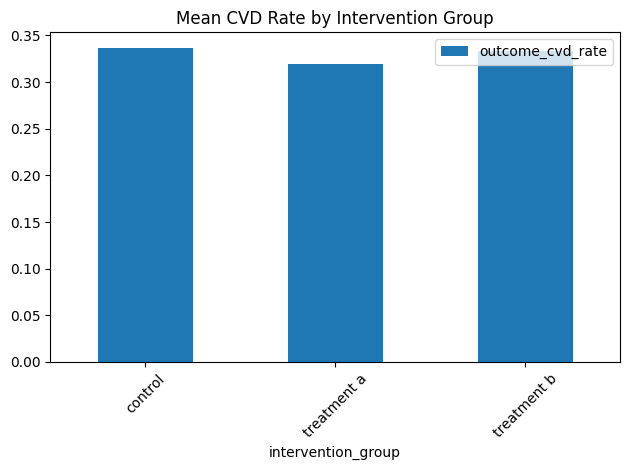

<Figure size 1000x600 with 0 Axes>

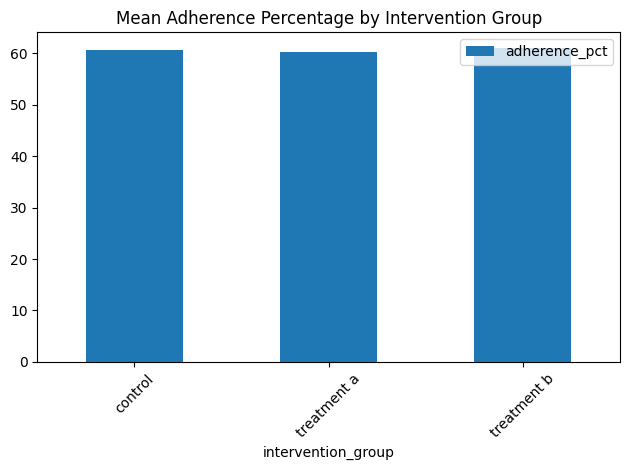

<Figure size 1000x600 with 0 Axes>

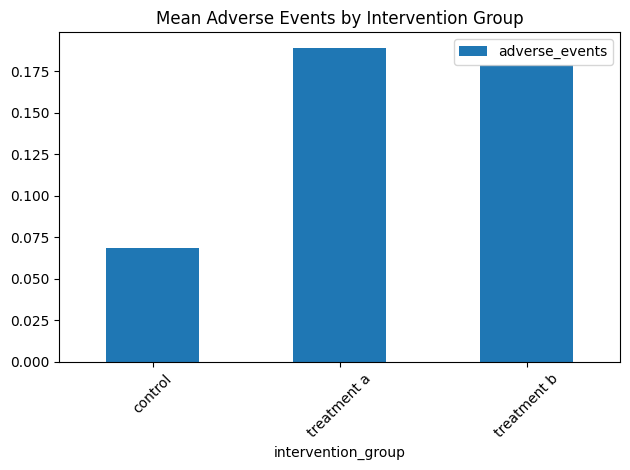

In [7]:
# TODO: Visualization
plot_group_comparison(interv_summary, x_col="intervention_group", y_col="outcome_cvd_rate", title="Mean CVD Rate by Intervention Group")
plot_group_comparison(interv_summary, x_col="intervention_group", y_col="adherence_pct", title="Mean Adherence Percentage by Intervention Group")
plot_group_comparison(interv_summary, x_col="intervention_group", y_col="adverse_events", title="Mean Adverse Events by Intervention Group")



## Part 4: Final Report

Create and save:
1. Summary statistics by site → `output/q7_site_summary.csv`
2. Intervention group comparison → `output/q7_intervention_comparison.csv`
3. Text report with key findings → `output/q7_analysis_report.txt`

In [8]:
# TODO: Save summary outputs

site_summary.to_csv("output/q7_site_summary.csv", index=False)
interv_summary.to_csv("output/q7_intervention_comparison.csv", index=False)

with open("output/q7_analysis_report.txt", "w") as f:
    f.write("=== Intervention Group Summary ===\n")
    f.write(interv_summary.to_string(index=False))
    f.write("\n\n=== Dropout Status by Intervention Group ===\n")
    f.write(dropout_crosstab.to_string())
    f.write("\n\n=== Key Findings ===\n")
    f.write("1. The mean adherence and cvd rates were very similar among the different intervention groups.\n")
    f.write("2. The mean adverse events for the control group was much lower than the treatment group.\n")
    f.write("3. Dropout appears highest in the control group, then treatment a then treatment b has the lowest number of dropouts.\n")





## Summary

What are the 3 most important findings from your analysis?

**Key Findings:**

1. The mean adherence and cvd rates were very similar among the different intervention groups.
2. The mean adverse events for the control group was much lower than the treatment group.
3. Dropout appears highest in the control group, then treatment a then treatment b has the lowest number of dropouts.

